In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
np.random.seed(42)
n = 100

cgpa = np.round(np.random.uniform(5.5,9.8,n), 2)
study_hours =  np.round(np.random.uniform(1, 10 , n), 1)
internship = np.random.randint(0,4,n)
projects = np.random.randint(1,6,n)

salary = (
    1.5
    + 0.65 * cgpa
    + 0.18 * study_hours
    + 0.75 * internship
    + 0.25 * projects
    + np.random.normal(0,0.5,n)    
)

salary = np.round(salary,2)

df = pd.DataFrame({
    'CGPA': cgpa,
    'Study_hours': study_hours,
    'Internship': internship,
    'Projects': projects,
    'Salary_LPA': salary    
})
print(df.head())
df.shape

   CGPA  Study_hours  Internship  Projects  Salary_LPA
0  7.11          1.3           3         5       10.21
1  9.59          6.7           3         5       12.74
2  8.65          3.8           2         1        9.32
3  8.07          5.6           0         3        7.46
4  6.17          9.2           3         2        9.71


(100, 5)

In [6]:
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nData Type:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

   CGPA  Study_hours  Internship  Projects  Salary_LPA
0  7.11          1.3           3         5       10.21
1  9.59          6.7           3         5       12.74
2  8.65          3.8           2         1        9.32
3  8.07          5.6           0         3        7.46
4  6.17          9.2           3         2        9.71

Dataset Shape:
(100, 5)

Data Type:
CGPA           float64
Study_hours    float64
Internship       int32
Projects         int32
Salary_LPA     float64
dtype: object

Statistical Summary:
             CGPA  Study_hours  Internship    Projects  Salary_LPA
count  100.000000   100.000000  100.000000  100.000000  100.000000
mean     7.521400     5.484000    1.570000    2.980000    9.329600
std      1.279464     2.637481    1.208179    1.456299    1.478246
min      5.520000     1.100000    0.000000    1.000000    5.270000
25%      6.327500     3.200000    0.000000    2.000000    8.192500
50%      7.495000     5.550000    2.000000    3.000000    9.190000
75%      8.64

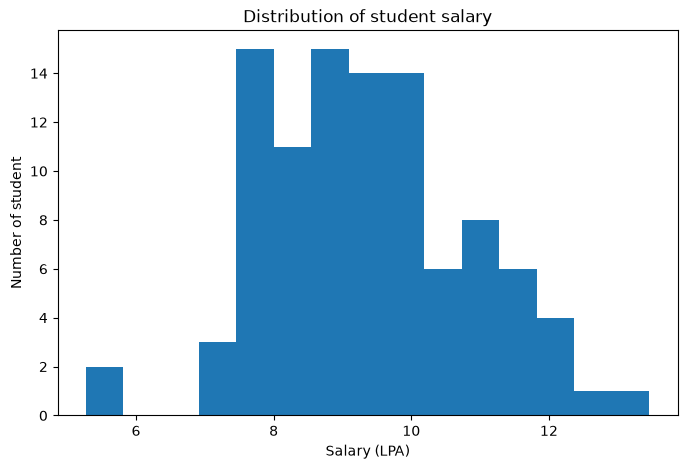

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df['Salary_LPA'],bins=15)

plt.xlabel('Salary (LPA)')
plt.ylabel('Number of student')
plt.title('Distribution of student salary')

plt.show()

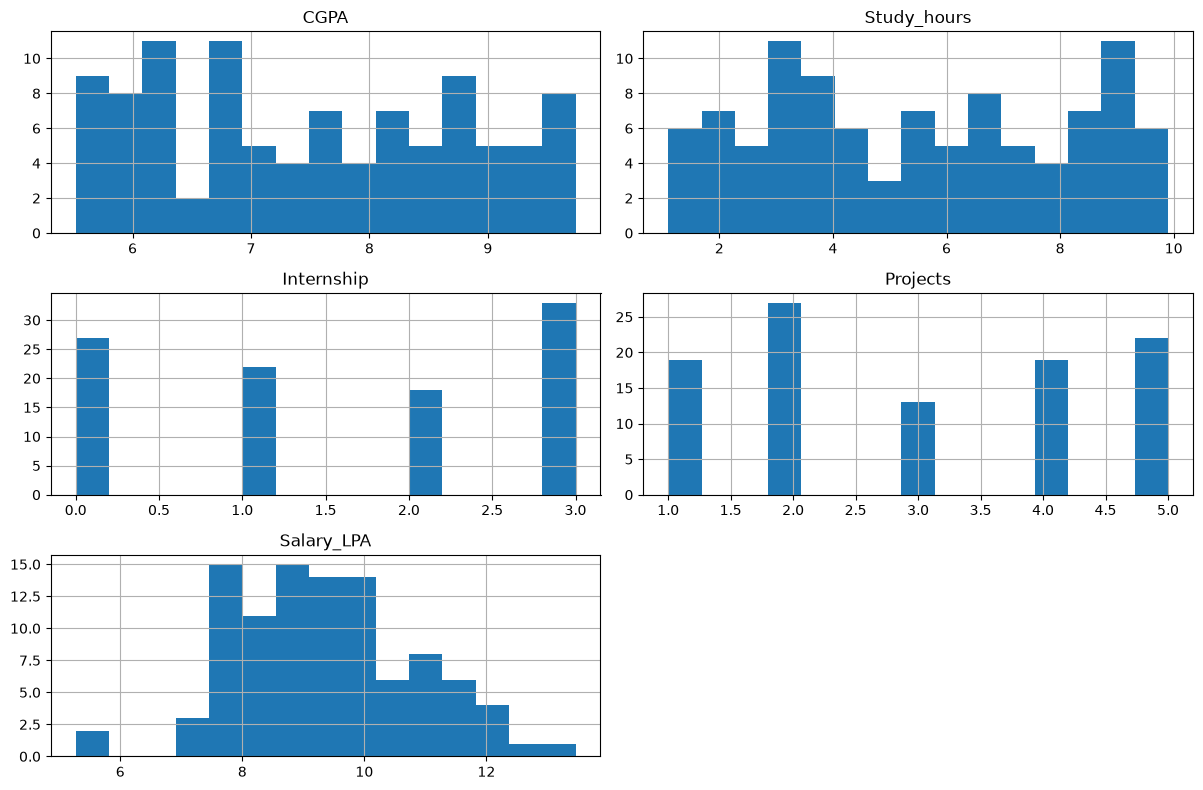

In [9]:
df.hist(
    figsize=(12,8),
    bins=15
)
plt.tight_layout()
plt.show()

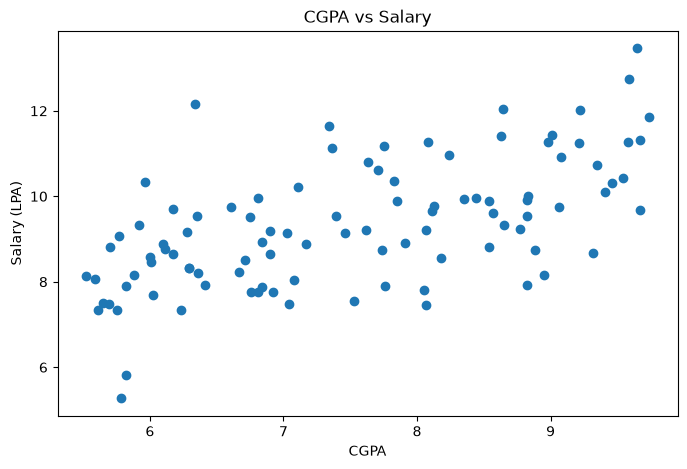

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['CGPA'],
    df['Salary_LPA']
)
plt.xlabel("CGPA")
plt.ylabel('Salary (LPA)')
plt.title('CGPA vs Salary')

plt.show()

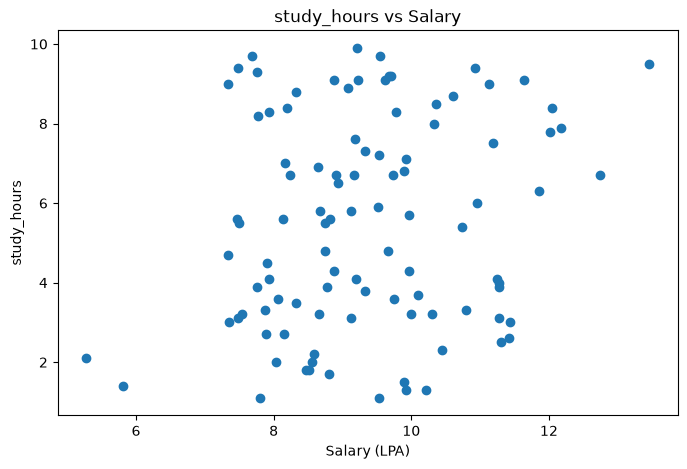

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Salary_LPA'],
    df['Study_hours']
    
)
plt.xlabel("Salary (LPA)")
plt.ylabel('study_hours')
plt.title('study_hours vs Salary')

plt.show()

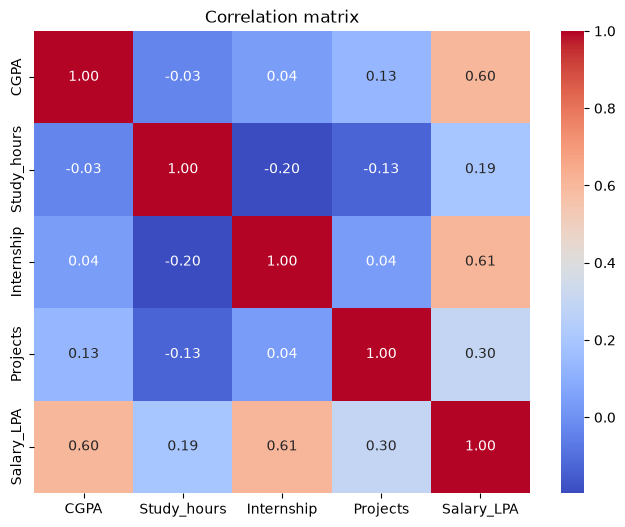

In [14]:
plt.figure(figsize=(8,6))
correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation matrix')
plt.show()

In [16]:
X = df[['CGPA',
        'Study_hours',
        'Internship',
        'Projects'
       ]]
y = df[['Salary_LPA']]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state = 42
)
print("Training data:",X_train.shape)
print("Testing data:",X_test.shape)

Training data: (80, 4)
Testing data: (20, 4)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[0.6 ,0.21,0.83,0.25]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['CGPA','Study_hours','Internship','Projects']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1.57]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [19]:
print('Intercept:')
print(model.intercept_)

print('/nCoefficiets:')

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(feature, ':', coefficient)

Intercept:
[1.57069967]
/nCoefficiets:
CGPA : [0.60138289 0.21237746 0.82893818 0.25261548]


In [20]:
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.values[:10])

print('\nPrediction values:')
print(y_pred[:10])

Actual values:
[[ 9.08]
 [10.73]
 [ 9.92]
 [ 9.93]
 [ 9.75]
 [ 9.55]
 [ 7.76]
 [11.25]
 [ 8.07]
 [10.21]]

Prediction values:
[[ 9.02285392]
 [10.17986809]
 [ 8.88800769]
 [ 9.53667581]
 [ 9.04982946]
 [ 9.98547242]
 [ 8.05110473]
 [10.71961371]
 [ 7.86009621]
 [ 9.87251469]]


In [27]:
y_pred[:10]

array([[ 9.02285392],
       [10.17986809],
       [ 8.88800769],
       [ 9.53667581],
       [ 9.04982946],
       [ 9.98547242],
       [ 8.05110473],
       [10.71961371],
       [ 7.86009621],
       [ 9.87251469]])

In [ ]:
result = pd.DataFrame({
    "Actual_Salary" : y_test.values,
    "Predicted_Salary" : np.round(y_pred, 2)
})
result.head()